In [3]:
import pandas as pd
# Membaca data CSV (pastikan nama file sesuai dengan yang ada di folder Anda)
df = pd.read_csv('ai4i2020.csv')
# Menampilkan 5 baris data teratas untuk memastikan data berhasil terbaca
df.head()

,UDI;Product ID;Type;Air temperature [K];Process temperature [K];Rotational speed [rpm];Torque [Nm];Tool wear [min];Machine failure;TWF;HDF;PWF;OSF;RNF
0,1;M14860;M;298.01.00;308.06.00;1551;42.08.00;0...
1,2;L47181;L;298.02.00;308.07.00;1408;46.03.00;3...
2,3;L47182;L;298.01.00;308.05.00;1498;49.04.00;5...
3,4;L47183;L;298.02.00;308.06.00;1433;39.05.00;7...
4,5;L47184;L;298.02.00;308.07.00;1408;40.00.00;9...


In [2]:
!pip install pandas openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 5.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 5.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [openpyxl]3/4 [openpyxl]


In [4]:
import pandas as pd

# Menambahkan sep=';' agar Python tahu datanya dipisahkan oleh titik koma
df = pd.read_csv('ai4i2020.csv', sep=';')

# Menampilkan kembali data teratas
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.01.00,308.06.00,1551,42.08.00,0,0,0,0,0,0,0
1,2,L47181,L,298.02.00,308.07.00,1408,46.03.00,3,0,0,0,0,0,0
2,3,L47182,L,298.01.00,308.05.00,1498,49.04.00,5,0,0,0,0,0,0
3,4,L47183,L,298.02.00,308.06.00,1433,39.05.00,7,0,0,0,0,0,0
4,5,L47184,L,298.02.00,308.07.00,1408,40.00.00,9,0,0,0,0,0,0


In [5]:
# Cek info tipe data dan nilai kosong
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   UDI                      10000 non-null  int64
 1   Product ID               10000 non-null  str  
 2   Type                     10000 non-null  str  
 3   Air temperature [K]      10000 non-null  str  
 4   Process temperature [K]  10000 non-null  str  
 5   Rotational speed [rpm]   10000 non-null  int64
 6   Torque [Nm]              10000 non-null  str  
 7   Tool wear [min]          10000 non-null  int64
 8   Machine failure          10000 non-null  int64
 9   TWF                      10000 non-null  int64
 10  HDF                      10000 non-null  int64
 11  PWF                      10000 non-null  int64
 12  OSF                      10000 non-null  int64
 13  RNF                      10000 non-null  int64
dtypes: int64(9), str(5)
memory usage: 1.1 MB


In [6]:
# 1. Kita bersihkan karakter aneh (jika ada titik ganda) dan paksa ubah menjadi angka float
df['Air temperature [K]'] = pd.to_numeric(df['Air temperature [K]'].astype(str).str.replace(r'(\.\d+)\..*', r'\1', regex=True), errors='coerce')
df['Process temperature [K]'] = pd.to_numeric(df['Process temperature [K]'].astype(str).str.replace(r'(\.\d+)\..*', r'\1', regex=True), errors='coerce')
df['Torque [Nm]'] = pd.to_numeric(df['Torque [Nm]'].astype(str).str.replace(r'(\.\d+)\..*', r'\1', regex=True), errors='coerce')

# 2. Cek ulang apakah tipenya sudah berubah menjadi float64
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [7]:
# Melihat rangkuman statistik angka desimal
df.describe()


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,299.597473,309.597356,1538.776100,39.578751,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.010921,1.506473,179.284096,9.974614,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.030000,305.070000,1168.000000,3.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.030000,308.080000,1423.000000,33.020000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.010000,310.010000,1503.000000,40.010000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.050000,311.010000,1612.000000,46.080000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.050000,313.080000,2886.000000,76.060000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
# Menghitung jumlah mesin normal (0) dan rusak (1)
print(df['Machine failure'].value_counts())

# Menghitung dalam bentuk persentase %
print(df['Machine failure'].value_counts(normalize=True) * 100)


Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [9]:
!pip install matplotlib seaborn


424.19s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 5.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 6.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


Matplotlib is building the font cache; this may take a moment.


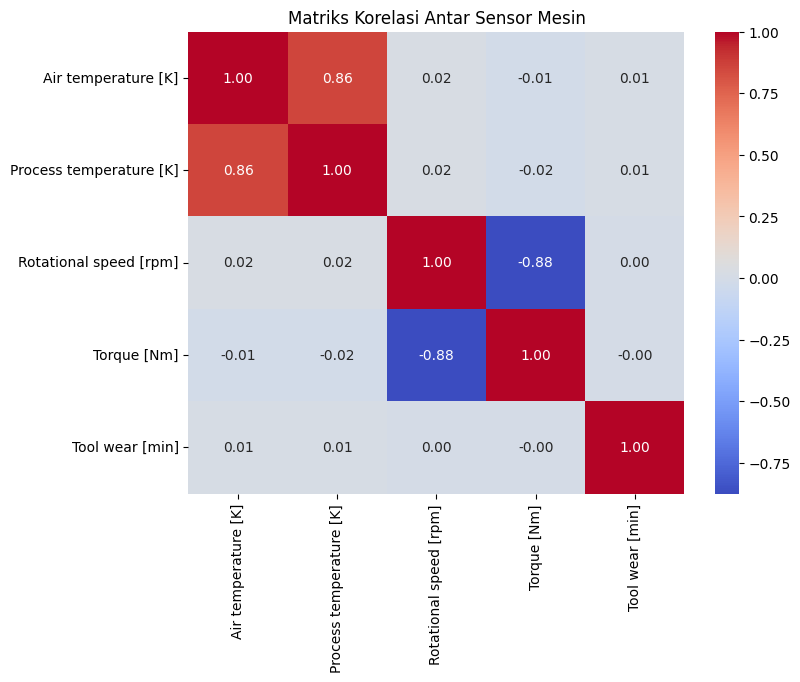

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memilih kolom sensor saja untuk dihitung korelasinya
sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Membuat matriks korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(df[sensor_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Antar Sensor Mesin')
plt.show()


In [11]:
# 1. Membuat fitur selisih suhu
df['Temperature difference [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

# 2. Menghapus kolom identitas yang tidak diperlukan oleh model Machine Learning
df_clean = df.drop(columns=['UDI', 'Product ID', 'Type'])

# 3. Menampilkan 5 baris teratas data baru kita
df_clean.head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature difference [K]
0,298.01,308.06,1551,42.08,0,0,0,0,0,0,0,10.05
1,298.02,308.07,1408,46.03,3,0,0,0,0,0,0,10.05
2,298.01,308.05,1498,49.04,5,0,0,0,0,0,0,10.04
3,298.02,308.06,1433,39.05,7,0,0,0,0,0,0,10.04
4,298.02,308.07,1408,40.00,9,0,0,0,0,0,0,10.05


In [12]:
!pip install scikit-learn


652.15s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 5.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 6.2 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Menentukan Fitur (X) dan Target yang ingin diprediksi (y)
# Kita kecualikan 'Machine failure' dan sub-tipe kegagalan (TWF, HDF, dll) dari X
X = df_clean.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df_clean['Machine failure']

# 2. Membagi data: 80% untuk latihan AI, 20% untuk menguji kepintaran AI
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Inisialisasi dan melatih Model AI (Random Forest)
# Kita tambahkan class_weight='balanced' untuk mengatasi masalah Imbalanced Data yang kita temukan tadi
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. Menyuruh AI menebak data ujian
y_pred = model.predict(X_test)

# 5. Menampilkan hasil skor performa kepintaran AI
print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))


Akurasi Model: 0.983

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.74      0.78      0.76        68

    accuracy                           0.98      2000
   macro avg       0.86      0.88      0.87      2000
weighted avg       0.98      0.98      0.98      2000



/var/folders/xj/1jgkm3_90mlcrccltty_4wjm0000gn/T/ipykernel_4108/716247056.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Sensor', data=feat_importances, palette='viridis')


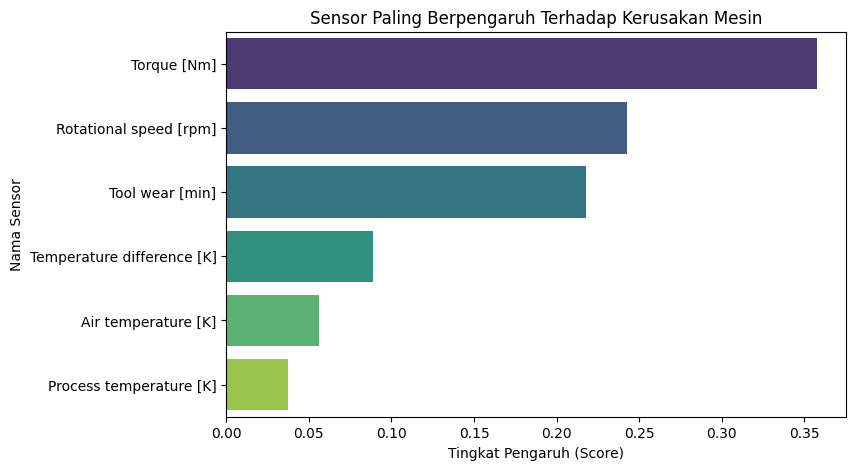

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengambil skor kepentingan fitur dari model Random Forest
importances = model.feature_importances_
feature_names = X.columns

# 2. Membuat DataFrame untuk visualisasi
feat_importances = pd.DataFrame({'Sensor': feature_names, 'Importance': importances})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# 3. Membuat grafik batang
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Sensor', data=feat_importances, palette='viridis')
plt.title('Sensor Paling Berpengaruh Terhadap Kerusakan Mesin')
plt.xlabel('Tingkat Pengaruh (Score)')
plt.ylabel('Nama Sensor')
plt.show()
